#MTH 5000 – Applied Forecasting of Financial Data
##Lecture 6: Moving Averages and ETS
---
Topics

*  1. Introduction to Moving Averages
*  2. Simple Moving Averages by Hand
*  3. Implementing Moving Averages
*  4. Introduction to ETS (Error-Trend-Seasonality) Models
*  5. Implementing ETS Models
*  6. Interactive Forecasting Graph


# 1. Introduction to Moving Averages


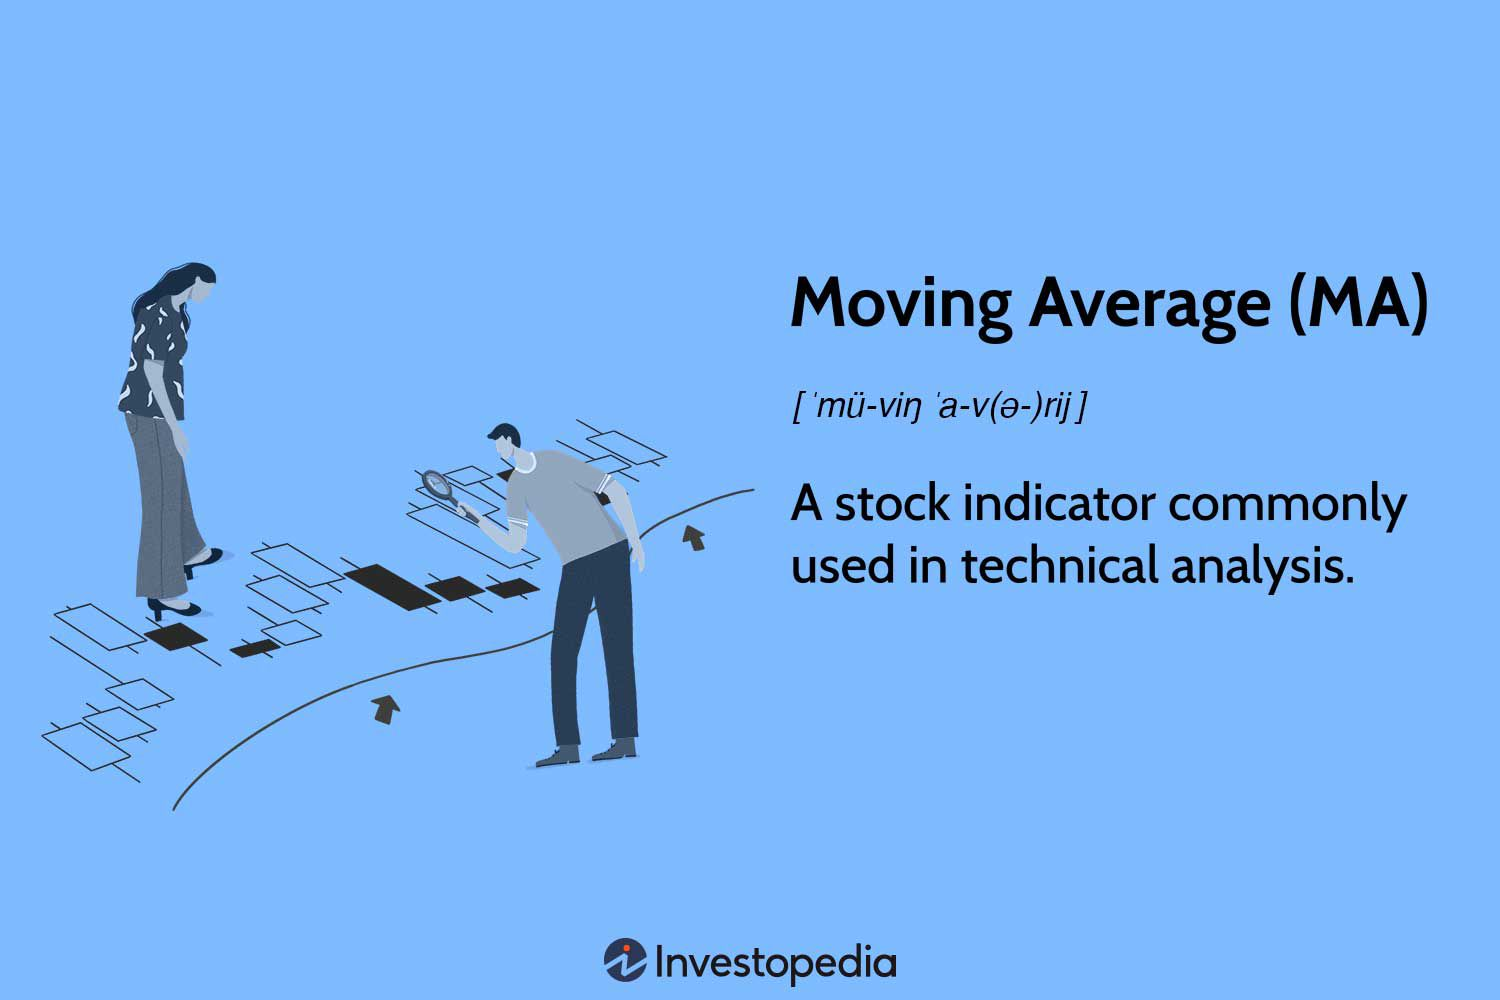

## Use Cases of Moving Averages

- **Trend Detection**
  - Smooth out short-term fluctuations to see the overall direction of a series.
  - Example: Monthly sales data showing upward or downward trends.

- **Seasonality & Noise Reduction**
  - Reduces random variations and highlights repeating patterns.
  - Useful in retail, energy consumption, or weather data.

- **Forecasting Preparation**
  - EMA or SMA can be used as a preprocessing step before models like ETS or ARIMA.
  - Helps models focus on the underlying signal rather than noise.

- **Anomaly Detection**
  - Sudden deviations from a moving average can signal unusual events.
  - Example: Detecting spikes in website traffic or sensor readings.

- **Financial & Stock Analysis**
  - EMA, SMA, and WMA are widely used to identify buy/sell signals.
  - Crossovers of short-term and long-term moving averages are common indicators.

- **Smoothing Inputs for Other Models**
  - Used to create lagged or smoothed features for machine learning models.
  - Reduces volatility in predictive features.

## Moving Averages Important for Time Series

- **Simple Moving Average (SMA)**
  - Often used for smoothing seasonal or noisy data.
  - Useful for short-term trend detection.

- **Exponential Moving Average (EMA)**
  - Responds faster to recent changes than SMA.
  - Common in time series modeling, especially when recent data is more relevant.

- **Weighted Moving Average (WMA)**
  - Can be useful if certain past periods are more important.
  - Less common than EMA in forecasting but helpful in some domain-specific cases.

- **Cumulative Moving Average (CMA)**
  - Rarely used for short-term forecasting.
  - Good for understanding overall trend over time.

- **Adaptive Moving Average (AMA)**
  - Advanced, adjusts smoothing based on volatility.
  - Useful in financial time series or highly volatile data.

> **In practice for time series forecasting**, SMA and EMA are the most widely used for pre-processing, smoothing, and identifying trend/seasonality. AMA or WMA are more specialized.

## Moving Averages Formulas

### 1. Simple Moving Average (SMA)
$$
SMA = \frac{A_1 + A_2 + A_3 + \dots + A_n}{n}
$$

### 2. Exponential Moving Average (EMA)
$$
\begin{aligned}
EMA_1 &= A_1 \quad \text{(initial value)} \\
EMA_2 &= \alpha \cdot A_2 + (1-\alpha) \cdot EMA_1 \\
EMA_3 &= \alpha \cdot A_3 + (1-\alpha) \cdot EMA_2 \\
&\;\;\vdots \\
EMA_t &= \alpha \cdot A_t + (1-\alpha) \cdot EMA_{t-1}
\end{aligned}
$$
- where $α$ is the smoothing factor for the Exponential Moving Average which determines how much weight the most recent observation gets relative to the previous EMA.

- Range: $0 < α \leq 1$

### 3. Weighted Moving Average (WMA)
$$
WMA = \frac{w_1 \cdot A_1 + w_2 \cdot A_2 + \dots + w_n \cdot A_n}{w_1 + w_2 + \dots + w_n}
$$
- $(w_i)$ = weight of the $(i)_{th}$ observation (usually more recent data has higher weight)

# 2. Simple Moving Averages by Hand



| Day | Sales (($A_t$)) | 3-Day SMA |
| --- | -----           | --------- |
| 1   | 10              | –         |
| 2   | 12              | –         |
| 3   | 11              | 11.00     |
| 4   | 14              | 12.33     |
| 5   | 13              | 12.66     |
| 6   | 15              | 14.00     |
| 7   | 16              | 14.66     |


Let us Calculate SMA for each day (starting from day 3)

The 3-day SMA smooths the daily sales data, reducing short-term fluctuations while highlighting the underlying trend. It lags behind sudden changes, illustrating the trade-off between smoothness and responsiveness.

#  3. Implementing Moving Averages


In [ ]:
# Program to calculate moving average
arr = [1, 2, 3, 7, 9]
window_size = 3

i = 0
# Initialize an empty list to store moving averages
moving_averages = []

# Loop through the array to consider
# every window of size 3
while i < len(arr) - window_size + 1:

    # Store elements from i to i+window_size
    # in list to get the current window
    window = arr[i : i + window_size]

    # Calculate the average of current window
    window_average = round(sum(window) / window_size, 2)

    # Store the average of current
    # window in moving average list
    moving_averages.append(window_average)

    print(moving_averages[i])

    # Shift window to right by one position
    i += 1
print(moving_averages)

2.0
4.0
6.33
[2.0, 4.0, 6.33]


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Forecasting_Cleaned.csv to Forecasting_Cleaned.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
data = pd.read_csv('Forecasting_Cleaned.csv', parse_dates=['Date'])
data.set_index('Date', inplace=True)

data = data.sort_index()  # ensure chronological order

target = 'Close'  # Forecasting variable

# Drop any missing values in Close to avoid ETS errors
series = data[target].dropna()

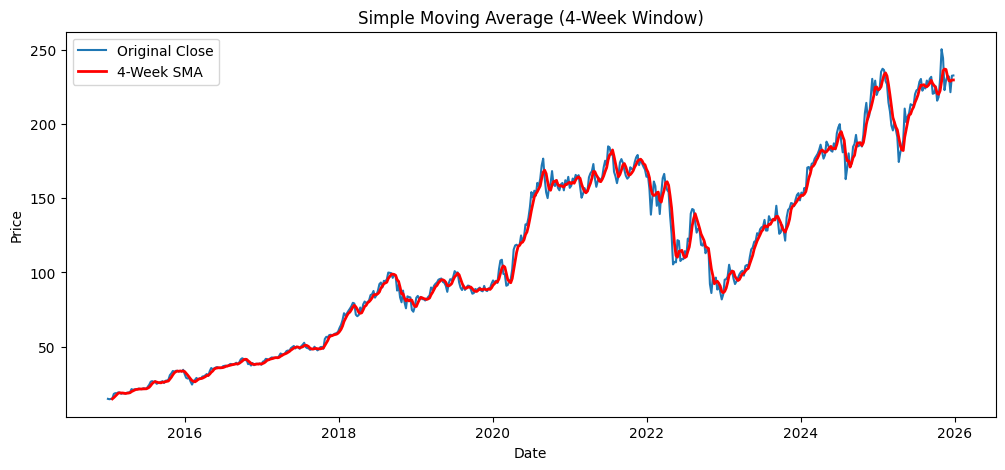

In [ ]:
# Simple Moving Average (SMA)
window = 4  # 4-week moving average
sma = series.rolling(window=window).mean()

plt.figure(figsize=(12,5))
plt.plot(series, label='Original Close')
plt.plot(sma, label=f'{window}-Week SMA', color='red', linewidth=2)
plt.title(f'Simple Moving Average ({window}-Week Window)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()


 - SMA smooths short-term fluctuations
 - Helps see overall trend
 - Larger window → smoother but slower to react

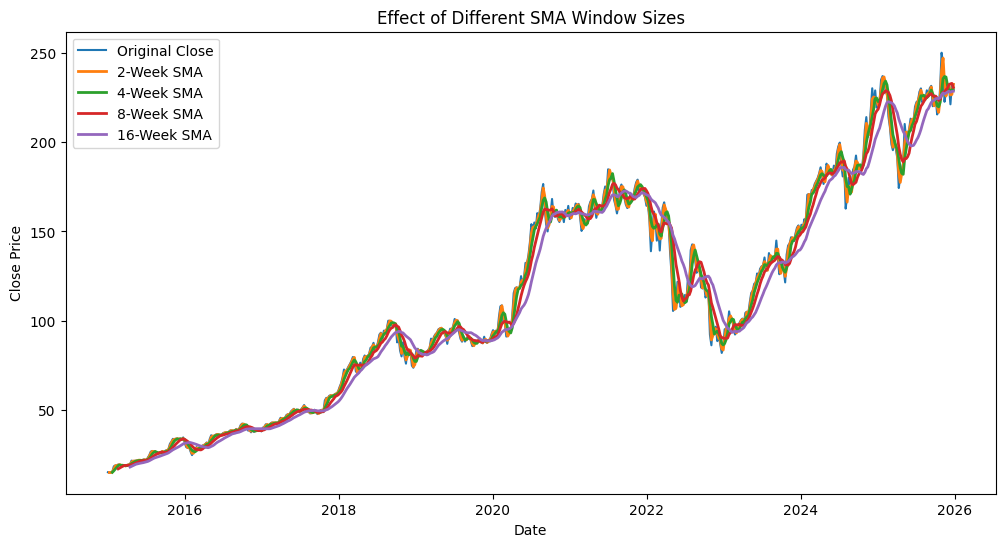

In [ ]:
# Visualizing SMA with different window sizes

window_sizes = [2, 4, 8, 16]  # example window sizes
plt.figure(figsize=(12,6))
plt.plot(series, label='Original Close', linewidth=1.5)

for w in window_sizes:
    sma = series.rolling(window=w).mean()
    plt.plot(sma, label=f'{w}-Week SMA', linewidth=2)

plt.title('Effect of Different SMA Window Sizes')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

 - Short windows (e.g., 2 weeks) follow the data closely, less smooth
 - Medium windows (e.g., 4–8 weeks) balance smoothness and responsiveness
 - Long windows (e.g., 16 weeks) smooth a lot but lag behind trends


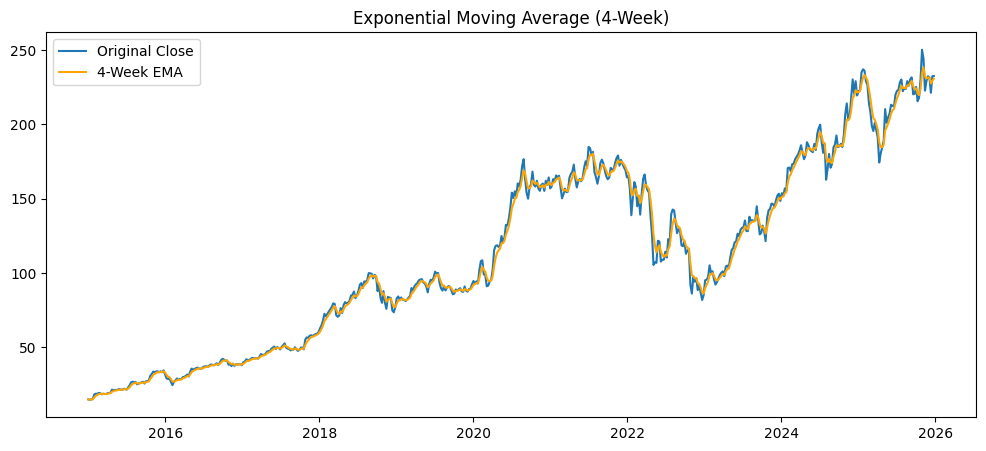

In [ ]:
# Exponential Moving Average
ema_4 = series.ewm(span=4, adjust=False).mean()
plt.figure(figsize=(12,5))
plt.plot(series, label='Original Close')
plt.plot(ema_4, label='4-Week EMA', color='orange')
plt.title('Exponential Moving Average (4-Week)')
plt.legend()
plt.show()

 - Faster reaction to recent changes.
 - Less lag than SMA, but still smooths noise.

### Overall **SMA** helps introduce basic smoothing and window effect while **EMA** shows faster reaction to changes.

# 4. Introduction to ETS (Error-Trend-Seasonality) Models

Recall from the previous lecture

 - Trend component → smooth long-term movement.

 - Seasonal component → repeating ups and downs within each period.

 - Residual (Error) → what remains after removing trend and seasonality.

In [ ]:
series

,Close
Date,
2015-01-01,14.921
2015-01-08,14.663
2015-01-15,14.863
2015-01-22,15.196
2015-01-29,18.237
...,...
2025-11-27,232.380
2025-12-04,231.780
2025-12-11,221.270


$ y = a*b*c $

$ y = a+b+c $

$ \log(y) = \log(a*b*c) = \log(y) = \log(a) + \log(b) + \log(c) $



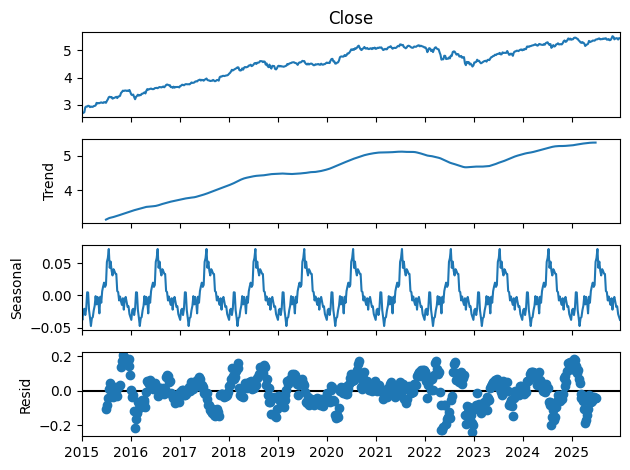

Decomposition of Log Series


In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
# Log-transform the Close series
ts_log = np.log(series)

# Additive decomposition on log series
decomp_log = seasonal_decompose(ts_log, model='additive', period=52)

# Plot decomposition
decomp_log.plot()
plt.show()

print('Decomposition of Log Series')

### ETS stands for Error, Trend, Seasonality. It is a classical forecasting framework used to model time series data by decomposing it into three components:

**Error (E)**:

 - Represents the random noise or unexplained variation in the data.
 - Can be additive (constant error) or multiplicative (error scales with level of the series).

**Trend (T)**:

 - Captures the long-term direction of the series.
 - Can be none, additive, or multiplicative.

Additive trend → grows linearly; Multiplicative trend → grows proportionally to the level.

**Seasonality (S)**:

 - Represents repeating patterns within a fixed period (e.g., weekly, monthly, yearly).
 - Can also be additive or multiplicative.

Additive seasonality → constant magnitude; Multiplicative seasonality → magnitude scales with series level.

###Why ETS is Useful for Forecasting

 - Unlike simple moving averages, ETS explicitly models trend and seasonality.
 - It can forecast future values by extending trend and seasonality patterns.
 - Provides a more realistic forecast for time series with regular patterns (like weekly sales or stock prices).

### Moving averages and ETS are connected because ETS models perform smoothing using exponentially weighted averages, which generalize the idea of a moving average.

 - Moving averages smooth a time series using equal weights over a fixed window.

 - ETS models use exponentially decaying weights, giving more importance to recent observations.

 - Thus, ETS can be viewed as an adaptive or infinite weighted moving average used for forecasting.

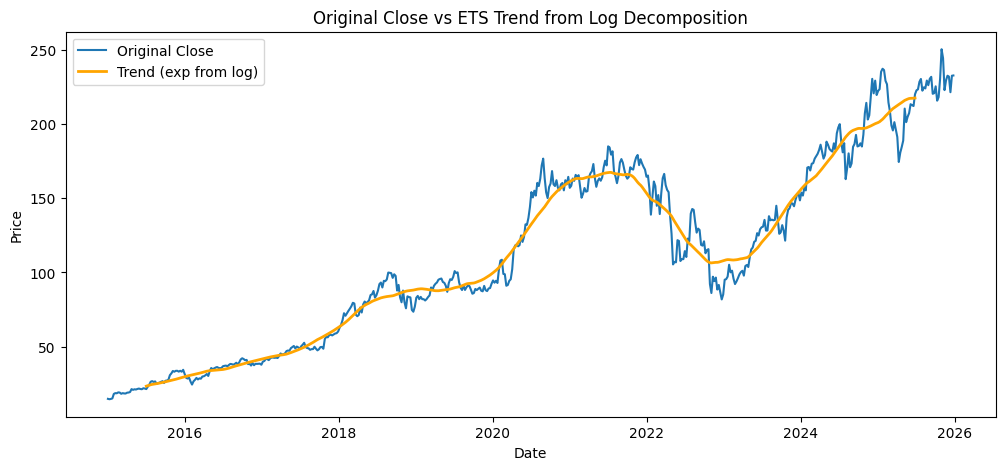

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(series, label='Original Close')
plt.plot(np.exp(decomp_log.trend), label='Trend (exp from log)', color='orange', linewidth=2)
plt.title('Original Close vs ETS Trend from Log Decomposition')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

#  5. Implementing ETS Models


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-THU will be used.
  self._init_dates(dates, freq)


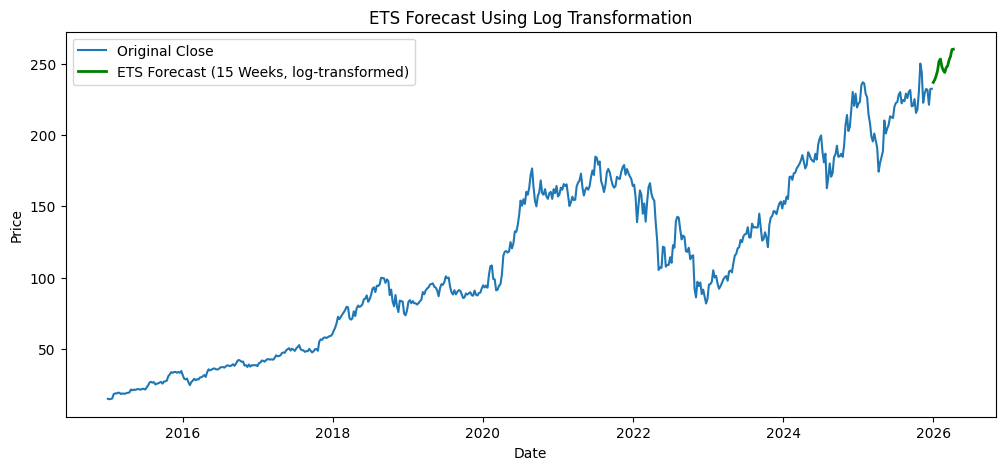

In [ ]:
# Simple ETS Forecast (Additive Trend + Seasonality)
# Fit additive ETS on log series
from statsmodels.tsa.holtwinters import ExponentialSmoothing
ets_log_model = ExponentialSmoothing(
    ts_log,
    trend='additive',
    seasonal='additive',
    seasonal_periods=52
).fit()

# Forecast 12 weeks in log scale
forecast_log = ets_log_model.forecast(15) #Play around with future forecast

# Convert forecast back to original scale
forecast = np.exp(forecast_log)

# Plot
plt.figure(figsize=(12,5))
plt.plot(series, label='Original Close')
plt.plot(forecast, label='ETS Forecast (15 Weeks, log-transformed)', color='green', linewidth=2)
plt.title('ETS Forecast Using Log Transformation')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

Fitted: 207.67

50 week: 248.600729

12 week :248.600729

In [ ]:
forecast

,0
2026-01-01,236.986436
2026-01-08,238.779673
2026-01-15,241.556056
2026-01-22,245.253263
2026-01-29,251.799607
2026-02-05,253.378364
2026-02-12,247.981532
2026-02-19,245.384973
2026-02-26,243.947657
2026-03-05,247.296998


 - Forecast extends trend + seasonal components
 - Compare to SMA: ETS accounts for seasonality

# 6. Interactive Forecasting Graph

In [ ]:
# Interactive Forecasting: MA & ETS for Forecasting_Cleaned.csv
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from IPython.display import display
import ipywidgets as widgets

# -------------------------
# 1. Load Dataset
# -------------------------
data = pd.read_csv('Forecasting_Cleaned.csv', parse_dates=['Date'])
data.set_index('Date', inplace=True)

target = 'Close'  # Forecasting variable

# Ensure weekly frequency
data = data.asfreq('W')

# Fill missing values (forward fill is safe for weekly financial data)
data[target] = data[target].ffill()

# Optional: Log transform for variance stabilization
data['Log_Close'] = np.log(data[target])

# -------------------------
# 2. Interactive Widgets
# -------------------------
sma_slider = widgets.IntSlider(value=4, min=1, max=20, step=1, description='SMA Window')
trend_dropdown = widgets.Dropdown(options=['additive', 'multiplicative', None], value='additive', description='Trend')
seasonal_dropdown = widgets.Dropdown(options=['additive', 'multiplicative', None], value='additive', description='Seasonal')
forecast_slider = widgets.IntSlider(value=12, min=4, max=52, step=4, description='Forecast Weeks')

# -------------------------
# 3. Update Function
# -------------------------
def update_forecast(sma_window, trend_type, seasonal_type, forecast_weeks):
    plt.figure(figsize=(12,6))

    # 3a. Simple Moving Average
    sma = series.rolling(window=sma_window).mean()
    plt.plot(series, label=f'Original {target}', linewidth=1.5)
    plt.plot(sma, label=f'{sma_window}-Week SMA', color='red', linewidth=2)

    # 3b. ETS Forecast (only if trend or seasonal is selected)
    if trend_type is not None or seasonal_type is not None:
        # ETS annual seasonality for weekly data
        ets_model = ExponentialSmoothing(
            series,
            trend=trend_type,
            seasonal=seasonal_type,
            seasonal_periods=52
        ).fit()
        forecast = ets_model.forecast(forecast_weeks)
        plt.plot(forecast, label='ETS Forecast', color='green', linewidth=2)

    plt.title(f'Interactive MA & ETS Forecast for {target}')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.show()

# -------------------------
# 4. Create Interactive UI
# -------------------------
interactive_plot = widgets.interactive(
    update_forecast,
    sma_window=sma_slider,
    trend_type=trend_dropdown,
    seasonal_type=seasonal_dropdown,
    forecast_weeks=forecast_slider
)

display(interactive_plot)

interactive(children=(IntSlider(value=4, description='SMA Window', max=20, min=1), Dropdown(description='Trend…

**Choose a window length that balances smoothing vs responsiveness.**

Short window → more responsive, less smooth

Long window → smoother, less responsive

**For forecasting values**

Near-term forecast: ETS is usually reliable, small errors.

Medium-term forecast: Uncertainty grows, trends dominate.

Long-term forecast: Trend and seasonality dominate, prediction intervals become huge, and the point forecast may be unrealistic.